# Log Space and Wave Intuition

for logspace, we have the formula: $10^{a + \delta k}$ to get N evenly spaced points between a, b in log-space. a, b are the exponents

- $\delta : \frac{b-a}{N-1}$ get the size of bins in an interval in the log-space
- N evenly spaced points in log-space: a, b are in the log space, and we divide into $a + k \delta = log(x_k) $ for k = 0, ..., N-1 evenly spaced points in **log space**:(x_0, x_1) are not evenly spaced!
- $v = a(b/a)^{f}$, where we traverse in increments of $f= \frac{k}{N-1}$ since log(v)
- $z^{(a+k \delta)} \Rightarrow  log_z(z^{(a+k \delta)}) \Rightarrow a+ k\delta$, so we sample $x= z^{(a+k \delta)}$ for each k to get linear spacing in log domain
- exponents: log domain axis
- can think of a one to one mapping between the values and  log(value) for the axis. 
- when we move on log scale, we multiply x instead of add to it. the spacing representings the strength of the ratio z^f needed to move to new value from the equation $x = z^y$ in our chosen exponential base
- since the scaling is exponential in f, the tilde marks on the logrithmic scale reflect this

In [4]:
import librosa
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import scipy
import sklearn

- we have a tone getting louder since we increase the amplitude logrithmically
- create a wave with $ y(t)= Asin(2\pi(f*t))$

[0.001      0.00158489 0.00251189 0.00398107 0.00630957 0.01
 0.01584893 0.02511886 0.03981072 0.06309573 0.1        0.15848932
 0.25118864 0.39810717 0.63095734]
15
0.001 0.6309573444801936


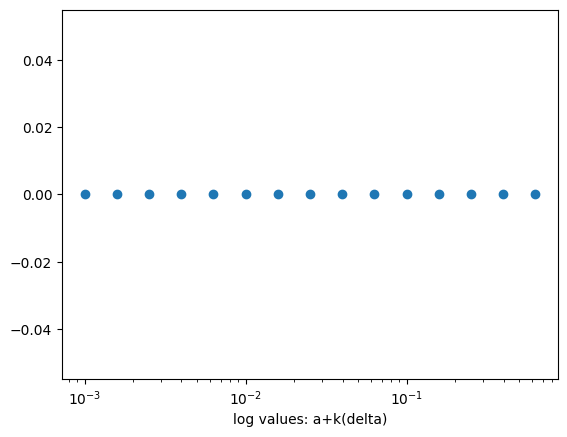

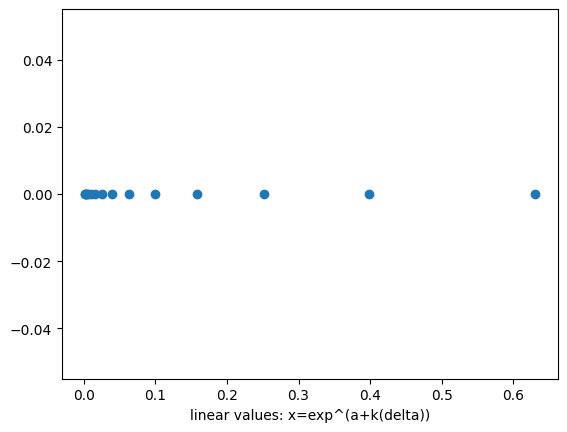

In [68]:
T = 3
sr = 5
amplitude = np.logspace(-3, 0, int(T*sr), endpoint = False, base = 10) #time-varying amplitude
y = np.zeros(int(T*sr))
print(amplitude)
print(len(amplitude))
print(amplitude.min(), amplitude.max())
plt.xscale('log')
plt.xlabel('log values: a+k(delta)')
plt.plot(amplitude, y, 'o')
plt.show()

plt.xscale('linear')
plt.xlabel('linear values: x=exp^(a+k(delta))')
plt.plot(amplitude, y, 'o')
plt.show()

sr = 22050
amplitude = np.logspace(-3, 0, int(T*sr), endpoint = False, base = 10) #time-varying amplitude
y = np.zeros(int(T*sr))
t= np.linspace(0, T, int(sr*T))
x = amplitude*np.sin(2*np.pi*440*t)




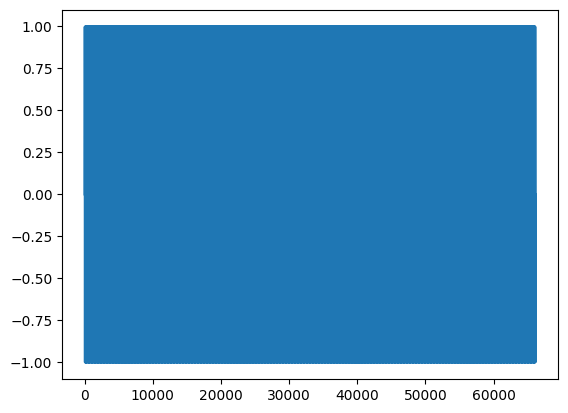

In [67]:
time = [t for t in range(int(T*sr))]
plt.plot(np.sin(2*np.pi*440*t))

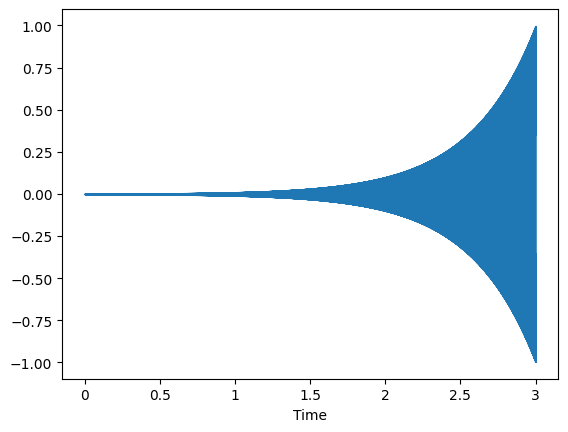

In [66]:
librosa.display.waveshow(x, sr=sr)

# Do segmentation and get RSME of each segment

In [70]:
# return an array of segmented audio ]
hop_length = 512
frame_l = 1024
def make_segments(signal, sr=22050, frame_l= 1024, hop_size=512):
    return[x[i: i+frame_l]for i in range(signal, step= hop_size)]

def RSME_segment(x):
    return np.sqrt(np.mean(x**2))

[np.float64(0.0007477725650914131),
 np.float64(0.0007866530125688625),
 np.float64(0.0008314469880718885),
 np.float64(0.0008764777527296897),
 np.float64(0.000924068096394836),
 np.float64(0.0009765782567077784),
 np.float64(0.0010274235943782365),
 np.float64(0.0010872755138777188),
 np.float64(0.0011434826129826758),
 np.float64(0.0012092436977551558),
 np.float64(0.0012738483700822833),
 np.float64(0.0013440078923960222),
 np.float64(0.0014194516954579282),
 np.float64(0.0014940414795368197),
 np.float64(0.0015807809800037602),
 np.float64(0.0016623014109625844),
 np.float64(0.0017586092866456065),
 np.float64(0.0018514162440116148),
 np.float64(0.001954815097642292),
 np.float64(0.002063066841816776),
 np.float64(0.0021727402650084772),
 np.float64(0.0022980856791050045),
 np.float64(0.002416724124192176),
 np.float64(0.0025573780568983),
 np.float64(0.0026909660296344554),
 np.float64(0.0028431953251967525),
 np.float64(0.002998423719143002),
 np.float64(0.003159943124252386),
 

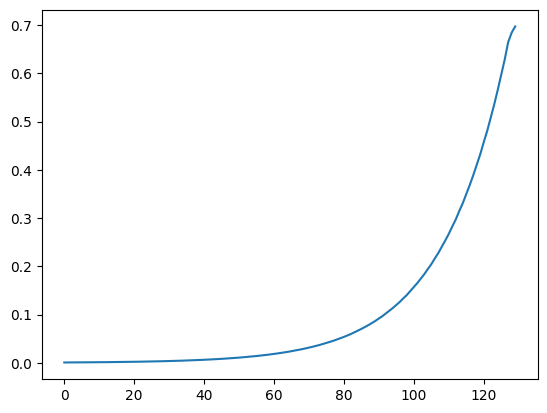

In [76]:
plt.plot([RSME_segment(x[i:i+frame_l]) for i in range(0, len(x), hop_length)])
display([RSME_segment(x[i:i+frame_l]) for i in range(0, len(x), hop_length)])

The plot below shows us a consistent ratio of increase for the rsme at higher frames

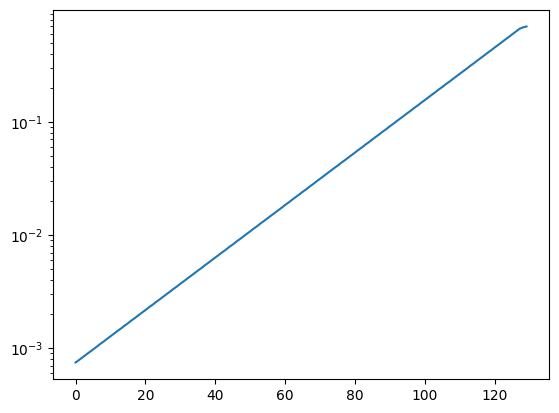

In [75]:
plt.semilogy([RSME_segment(x[i:i+frame_l]) for i in range(0, len(x), hop_length)])